

# 1.   Image Classification :

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


# 2. Data :

In [ ]:
# Preprocessing
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform_test
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

classes = train_dataset.classes
print('Train size:', len(train_dataset))
print('Test size: ', len(test_dataset))
print('Classes:   ', classes)

100%|██████████| 170M/170M [00:30<00:00, 5.57MB/s]


Train size: 50000
Test size:  10000
Classes:    ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Visualize Sample Images

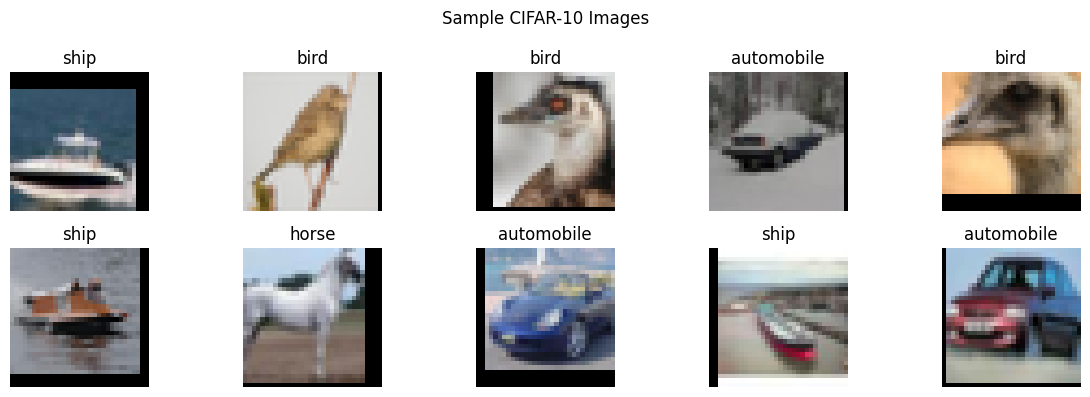

In [ ]:
plt.figure(figsize=(12, 4))
for i in range(10):
    img, label = random.choice(train_dataset)
    img = img.permute(1, 2, 0) * 0.5 + 0.5
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.clamp(0, 1))
    plt.title(classes[label])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images')
plt.tight_layout()
plt.show()



# 4.   Model :

In [ ]:
def build_model():
    model = nn.Sequential(
        # Block 1
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        # Block 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        # Block 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),

        # Classifier
        nn.AdaptiveAvgPool2d((4, 4)),
        nn.Flatten(), # vector
        nn.Linear(128 * 4 * 4, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 10)
    )
    return model.to(device)

Model architecture ready!


# 5. Training :

In [1]:
def train_and_evaluate(model, model_name, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    print(f'\n===== Training {model_name} =====')

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct    += (torch.argmax(outputs, 1) == labels).sum().item()
            total      += labels.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                correct  += (torch.argmax(outputs, 1) == labels).sum().item()
                total    += labels.size(0)

        val_losses.append(val_loss / len(test_loader))
        val_accs.append(100 * correct / total)

        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.2f}% | '
              f'Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

# 7. Experimentation :

In [ ]:
model_A    = build_model()
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=0.001)

tl_A, vl_A, ta_A, va_A = train_and_evaluate(
    model_A, 'Experiment 1 - Adam lr=0.001', optimizer_A, epochs=10
)

print(f'\nFinal Test Accuracy (Experiment 1): {va_A[-1]:.2f}%')


===== Training Experiment 1 - Adam lr=0.001 =====
Epoch 1/10 | Train Loss: 1.6127 | Train Acc: 39.93% | Val Loss: 1.1932 | Val Acc: 56.97%
Epoch 2/10 | Train Loss: 1.3135 | Train Acc: 52.19% | Val Loss: 1.0398 | Val Acc: 62.83%
Epoch 3/10 | Train Loss: 1.1913 | Train Acc: 57.37% | Val Loss: 0.9275 | Val Acc: 66.97%
Epoch 4/10 | Train Loss: 1.1017 | Train Acc: 60.76% | Val Loss: 0.8455 | Val Acc: 69.79%
Epoch 5/10 | Train Loss: 1.0449 | Train Acc: 63.36% | Val Loss: 0.7989 | Val Acc: 71.57%
Epoch 6/10 | Train Loss: 0.9866 | Train Acc: 65.67% | Val Loss: 0.7627 | Val Acc: 73.08%
Epoch 7/10 | Train Loss: 0.9415 | Train Acc: 67.44% | Val Loss: 0.7202 | Val Acc: 74.88%
Epoch 8/10 | Train Loss: 0.9015 | Train Acc: 69.03% | Val Loss: 0.6767 | Val Acc: 76.35%
Epoch 9/10 | Train Loss: 0.8578 | Train Acc: 70.67% | Val Loss: 0.6682 | Val Acc: 76.79%
Epoch 10/10 | Train Loss: 0.8271 | Train Acc: 71.74% | Val Loss: 0.6717 | Val Acc: 77.26%

Final Test Accuracy (Experiment 1): 77.26%


In [ ]:
model_B     = build_model()
optimizer_B = torch.optim.SGD(model_B.parameters(), lr=0.01, momentum=0.9)

tl_B, vl_B, ta_B, va_B = train_and_evaluate(
    model_B, 'Experiment 2 - SGD lr=0.01', optimizer_B, epochs=10
)

print(f'\nFinal Test Accuracy (Experiment 2): {va_B[-1]:.2f}%')


===== Training Experiment 2 - SGD lr=0.01 =====
Epoch 1/10 | Train Loss: 1.8440 | Train Acc: 30.86% | Val Loss: 1.4598 | Val Acc: 46.54%
Epoch 2/10 | Train Loss: 1.5053 | Train Acc: 44.56% | Val Loss: 1.0868 | Val Acc: 61.20%
Epoch 3/10 | Train Loss: 1.2441 | Train Acc: 55.68% | Val Loss: 1.0356 | Val Acc: 63.06%
Epoch 4/10 | Train Loss: 1.0888 | Train Acc: 61.79% | Val Loss: 0.8818 | Val Acc: 68.39%
Epoch 5/10 | Train Loss: 0.9892 | Train Acc: 65.71% | Val Loss: 0.8083 | Val Acc: 71.05%
Epoch 6/10 | Train Loss: 0.9190 | Train Acc: 68.37% | Val Loss: 0.7305 | Val Acc: 74.24%
Epoch 7/10 | Train Loss: 0.8617 | Train Acc: 70.36% | Val Loss: 0.7261 | Val Acc: 74.31%
Epoch 8/10 | Train Loss: 0.8177 | Train Acc: 72.00% | Val Loss: 0.7075 | Val Acc: 75.69%
Epoch 9/10 | Train Loss: 0.7813 | Train Acc: 73.08% | Val Loss: 0.6381 | Val Acc: 78.30%
Epoch 10/10 | Train Loss: 0.7470 | Train Acc: 74.29% | Val Loss: 0.6538 | Val Acc: 77.52%

Final Test Accuracy (Experiment 2): 77.52%


# 8. Visualization :

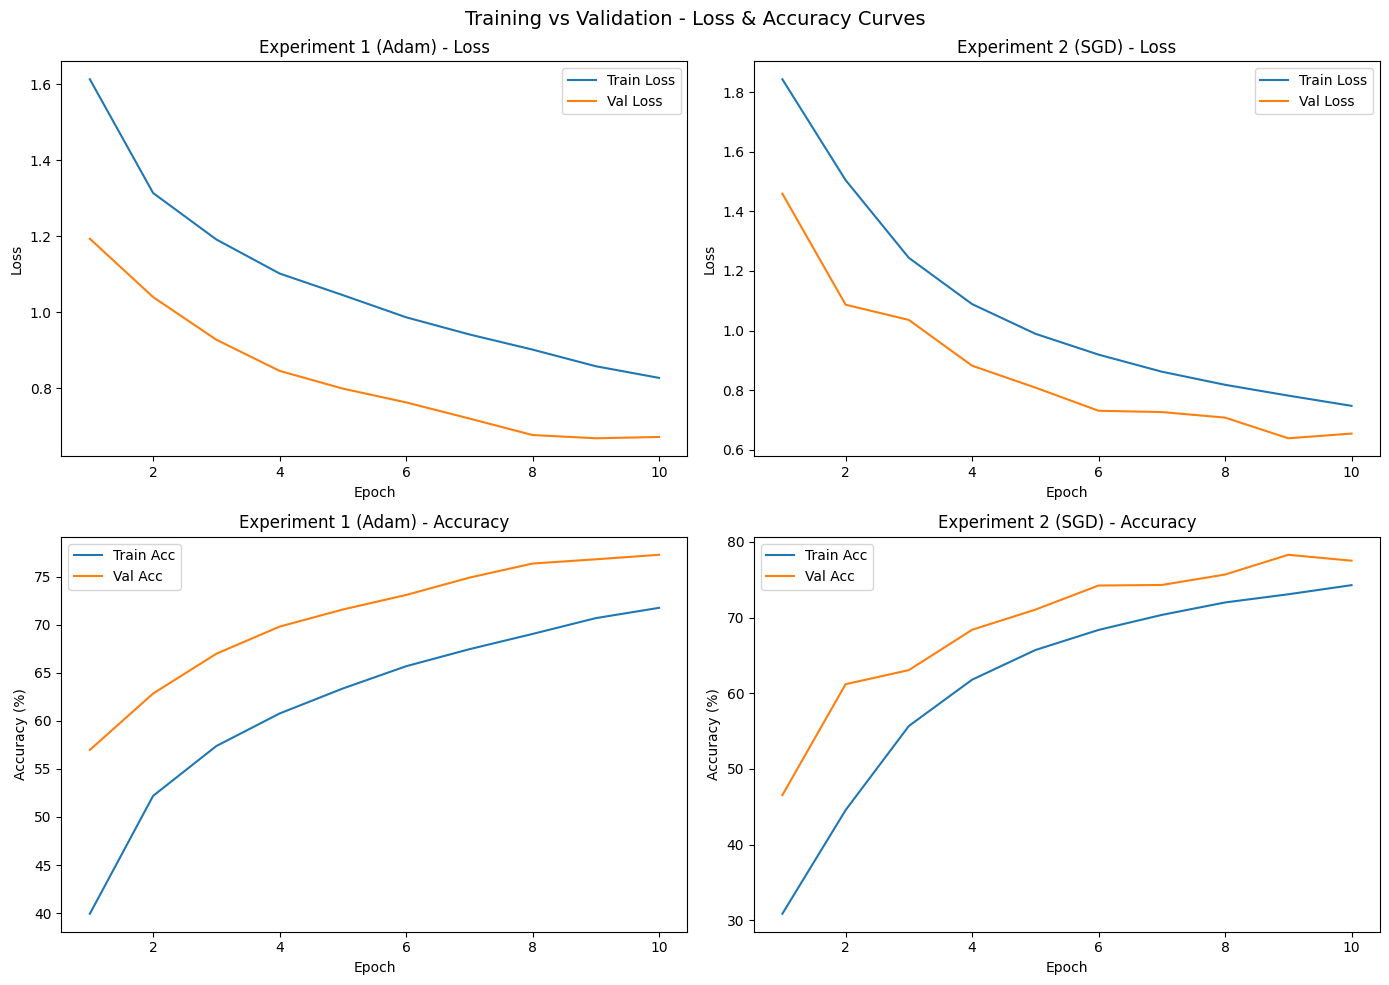

In [ ]:
epochs_range = range(1, 11)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
axes[0, 0].plot(epochs_range, tl_A, label='Train Loss')
axes[0, 0].plot(epochs_range, vl_A, label='Val Loss')
axes[0, 0].set_title('Experiment 1 (Adam) - Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(epochs_range, tl_B, label='Train Loss')
axes[0, 1].plot(epochs_range, vl_B, label='Val Loss')
axes[0, 1].set_title('Experiment 2 (SGD) - Loss')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

#  Accuracy curves
axes[1, 0].plot(epochs_range, ta_A, label='Train Acc')
axes[1, 0].plot(epochs_range, va_A, label='Val Acc')
axes[1, 0].set_title('Experiment 1 (Adam) - Accuracy')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()

axes[1, 1].plot(epochs_range, ta_B, label='Train Acc')
axes[1, 1].plot(epochs_range, va_B, label='Val Acc')
axes[1, 1].set_title('Experiment 2 (SGD) - Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()

plt.suptitle('Training vs Validation - Loss & Accuracy Curves', fontsize=14)
plt.tight_layout()
plt.show()

# 9. Results :

In [ ]:
print('=' * 55)
print(f'{"Model":<30} {"Accuracy":>10} {"Loss":>10}')
print('=' * 55)
print(f'{"Experiment 1 (Adam lr=0.001)":<30} {va_A[-1]:>9.2f}% {vl_A[-1]:>10.4f}')
print(f'{"Experiment 2 (SGD  lr=0.01)":<30} {va_B[-1]:>9.2f}% {vl_B[-1]:>10.4f}')
print('=' * 55)

Model                            Accuracy       Loss
Experiment 1 (Adam lr=0.001)       77.26%     0.6717
Experiment 2 (SGD  lr=0.01)        77.52%     0.6538
